# Hoja de trabajo - Torneo del Dilema del prisionero iterado

### Descripción del campeonato
Vamos a ver las condiciones del torneo. Hay tres fases en esta competición:
 - Fase de enfrentamiento directo entre estrategias
 - Fase evolutiva
 - Fase evolutiva dentro del ecosistema completo del DPI


#### Fase de enfrentamiento directo entre estrategias

Se jugará un torneo de *todos contra todos*: te enfrentarás a las estrategias de tus rivales dos veces. El resultado que obtengas en cada enfrentamiento se sumará a los ya obtenidos hasta el momento. Ganará la estrategia con más puntos al final de las interacciones. Las condiciones concretas son las siguientes:
 - El dilema del prisionero que se usará será el siguiente:

<center>

|      |  C    |  D    |
|------|-------|-------|
|   C  | 2, 2  | -1, 3 |
|   D  | 3, -1 |  0, 0 |

</center>

 - La probabilidad de acabar el enfrentamiento tras cada ronda $P_{end}$ se fija en 1%, con un máximo de rondas de 500.
 - La probabilidad de error $P_{error}$ se fija en 1%.
 - Se jugará 2 veces contra cada rival.

Se asignarán los siguientes puntos según la posición final:
 - 5º y 6º clasificados: 4 puntos
 - 4º clasificado: 8 puntos
 - 3º clasificado: 12 puntos
 - 2º clasificado: 17 puntos
 - 1º clasificado: 24 puntos 


#### Fase evolutiva

Las estrategias se enfrentarán en un torneo evolutivo, en el que todos parten con el mismo número de representantes. Las condiciones para cada generación son las mismas que en la fase anterior. 

Aquí la evaluación de los ganadores puede ser complicada. En principio, el orden en el que se extingan las estrategias indicará el ranking de esta fase. No obstante, en ocasiones surgen situaciones difíciles de evaluar (por ejemplo, comportamientos cíclicos de dominancia de varias estrategias). En este tipo de escenarios, será el profesor decida qué estrategias han sido las más exitosas y su orden. Los puntos que pueden obtenerse en esta fase son los siguientes:
 - 3º clasificado: 12 puntos
 - 2º clasificado: 17 puntos
 - 1º clasificado: 24 puntos 

#### Fase evolutiva dentro del ecosistema completo del DPI

En esta fase, tu estrategia se enfrentará en un gran torneo evolutivo, donde estarán incluidas las estrategias de tus compañeros, pero también hasta 50 estrategias adicionales del ecosistema del DPI. Estarán las que ya conoces (TFT, Grudger, etc.), y también las estrategias que se han mostrado más exitosas en las últimas publicaciones científicas. De nuevo, el criterio general para establecer el ranking entre nuestras estrategias será: "cuanto más tarde se extingan tus individuos, más alto estarás en el ranking". Al tener tantas estrategias, esta parte del campeonato es la más susceptible a presentar situaciones difíciles de evaluar, por lo que en última instancia será el profesor quien, partiendo de criterios objetivos, seleccione las tres estrategias más exitosas, que se llevarán:
 - 3º clasificado: 4 puntos
 - 2º clasificado: 8 puntos
 - 1º clasificado: 12 puntos

Los puntos de las tres fases se sumarán y **el ganador obtendrá 1/10 puntos extra en la evaluación de LA PRIMERA PRUEBA DE LASE (martes 11)** (pudiendo obtener una nota superior a 10).

***
## [NO TOCAR] Definiciones generales

Estas líneas cargan las librerías necesarias para poder llevar a cabo el torneo. ¡NO LAS TOQUES! O puede que el resto del documento deje de funcionar como esperas

In [2]:
#@title

#Definiciones generales
%matplotlib inline

import seaborn
import axelrod
# Definiciones para estrategias
from axelrod.action import Action, actions_to_str
from axelrod.player import Player
from axelrod.strategy_transformers import FinalTransformer, TrackHistoryTransformer
from random import random

C, D = Action.C, Action.D

***
## Definición de tu estrategia
Aquí es donde vas a definir tu nueva estrategia. Fíjate cómo he hecho yo la mía. Pasos:
* Fíjate que el nombre de la clase es mi nombre. ¡Cámbialo por el tuyo para que sepamos que es tu estrategia!
* La primera definición dentro de la classe es el nombre de tu estrategia (```name```). Piensa cómo quieres llamarla y escríbelo ahí.
* De momento, ignora la definición de la función ```__init__()```.
* En la función llamada ```strategy()``` es donde vas a implementar el cuerpo de tu estrategia. No cambies la primera linea (```def strategy(self, opponent: Player) -> Action:```). ¡El resto de la función puedes modificarlo a tu gusto! La idea es que la función devuelva tu acción (```C``` - cooperar, o ```D``` - desertar) según las condiciones. Cosas que pueden resultarte útiles a la hora de definir tu estrategia:
    * ```len(opponent.history)```: turnos jugados hasta el momento. Si los vas a usar para algo, puedes definirte una variable llamada ```turns``` al inicio de la función (como he hecho yo).
    * ```opponent.history```: todos los movimientos DEL OPONENTE almacenados en una lista. Para acceder al último movimiento, ```opponent.history[-1]```.
    * ```self.history```: todos los movimientos PROPIOS almacenados en una lista. Para acceder al último movimiento, ```self.history[-1]```.
    * ```random()```: devuelve un número aleatorio entre 0 y 1. Por ejemplo, para hacer "algo" con un 5% de probabilidad, podría usarse una condición tipo: ```if (random()>0.05):```.
    
Esta es la única parte que tienes que modificar, y la que tendrás que enviarme para participar en el torneo. No obstante, si quieres puedes utilizar el resto del documento para hacer pruebas y mejorar tu estrategia.

\[No lo recomiendo, pero si necesitas inspiración desesperadamente, puedes buscar en Internet sobre estrategias para juegar al dilema del prisionero iterado. Mira por ejemplo [esta web](https://medium.com/thinking-is-hard/a-prisoners-dilemma-cheat-sheet-4d85fe289d87) \]

A continuación se incluye un ejemplo de implementación de una estrategia. De echo, este ejemplo será la estrategia del profesor, ¡y participará en el campeonato! Así que ya sabes una de las estrategias que va a estar presente. 

In [ ]:
class Destructomatic(Player):
    name = "Destructomatic"
    def __init__(self):
        """..."""
        super().__init__()

    def strategy(self, opponent: Player) -> int:
        """
        Starts cooperating.
        Protective against random players.
        Very occasionally, it defects.
        But in general is quite forgiven
        """

        turns = len(self.history)

        if turns < 4:  # I don't want any trouble, my friend (at least now)
            return C

        count_D_opponent = opponent.history.defections  # Num. of defections of the opponent

        # Aiming to improve performance against random or pseudo-random opponents
        if turns > 40 and 0.4 < count_D_opponent / turns < 0.6:  # you look random, mdfk!
            return D

        # Hoping to take advantage of very cooperative strategies
        if count_D_opponent < (turns / 10) and opponent.history[-2:]==[C, C]:  # you're too cooperative! let's have some fun, isn't?
            return D

        # Ok, but in general I'm very forgiving, as you see
        if opponent.history[-2:] != [D, D]:
            return C

        # Otherwise
        return D


***
## Comportamiento frente a una estrategia particular

Si te interesa analizar cómo se comporta tu estrategia contra otra en particular, este es el lugar para hacerlo. Define un set de jugadores (```players```), define un enfrentamiento (```match```) y simulalo. Puedes usar algunas de las estrategias típicas ya programadas:
* ```axelrod.Alternator()```: Alterna coperación-deserción infinitamente.
* ```axelrod.Cooperator()```: Siempre coopera.
* ```axelrod.Defector()```: Siempre deserta.
* ```axelrod.Grudger()```: Siempre coopera hasta que el oponente deserta. A partir de ahí, siempre deserta
* ```axelrod.TitForTat()```: Coopera en la primera ronda. Después, copia el último movimiento del contrario.
* ```axelrod.Random()```: Juega aleatoriamente coperación-deserción.
* ```axelrod.Detective()```: Empieza jugando CDCC. Si el oponente siempre ha cooperado, a partir de aquí juega siempre D. Si no, juega TitForTat.
* ```axelrod.Adaptive()```: Empieza jugando C,C,C,C,C,C,D,D,D,D,D. Luego, realiza la acción que le haya reportado más puntos en el pasado (se va adaptando).
* ```axelrod.SuspiciousTitForTat()```: Como TitForTat pero empieza desertando.
* ```axelrod.TitFor2Tats()```: Empieza cooperando y deserta solo después de DOS deserciones consecutivas del rival.

In [4]:
players = (Destructomatic(), axelrod.Random())
match = axelrod.Match(players, 10)
matchPlay = match.play()
matchScores = match.scores()

#Print results
print("Estrategias:", players[0].name, "|", players[1].name)
print("------------")
for i, var in enumerate(matchPlay):
    # Convert NumPy integers to Python integers
    score1 = int(matchScores[i][0])
    score2 = int(matchScores[i][1])
    print(f"Ronda {i+1} resultado:  {matchPlay[i]} | ({score1}, {score2})")
print("------------")

# Convert final scores to integers for cleaner output
final_scores = match.final_score()
final_score1 = int(final_scores[0])
final_score2 = int(final_scores[1])
print(f">>> Resultado final: ({final_score1}, {final_score2})    Ganador: {match.winner()}  Cooperación: {match.normalised_cooperation()}")

Estrategias: Destructomatic | Random
------------
Ronda 1 resultado:  (C, D) | (0, 5)
Ronda 2 resultado:  (C, C) | (3, 3)
Ronda 3 resultado:  (C, D) | (0, 5)
Ronda 4 resultado:  (C, C) | (3, 3)
Ronda 5 resultado:  (C, D) | (0, 5)
Ronda 6 resultado:  (C, C) | (3, 3)
Ronda 7 resultado:  (C, C) | (3, 3)
Ronda 8 resultado:  (C, C) | (3, 3)
Ronda 9 resultado:  (C, C) | (3, 3)
Ronda 10 resultado:  (C, C) | (3, 3)
------------
>>> Resultado final: (21, 36)    Ganador: Random: 0.5  Cooperación: (1.0, 0.7)


***
## Enfrentamiento directo
La primera modalidad de nuestro torneo. Todas las estrategias presentadas se enfrentarán entre ellas. La probabilidad de acabar el enfrentamiento $P_{end}$ se fija en 1%, con un número máximo de rondas de 200. La probabilidad de error $P_{error}$ se fija en 1%. **Gana quien mejor resultado promedio obtenga** (ver gráfica generada).

Analysing: 100%|██████████| 25/25 [00:00<00:00, 169.85it/s]


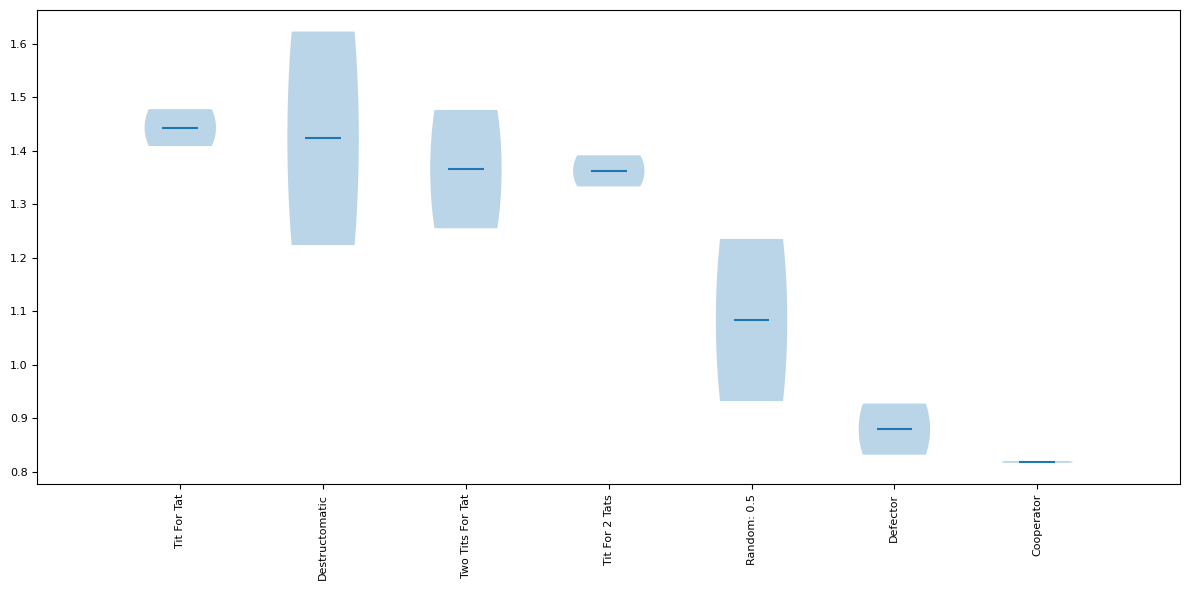

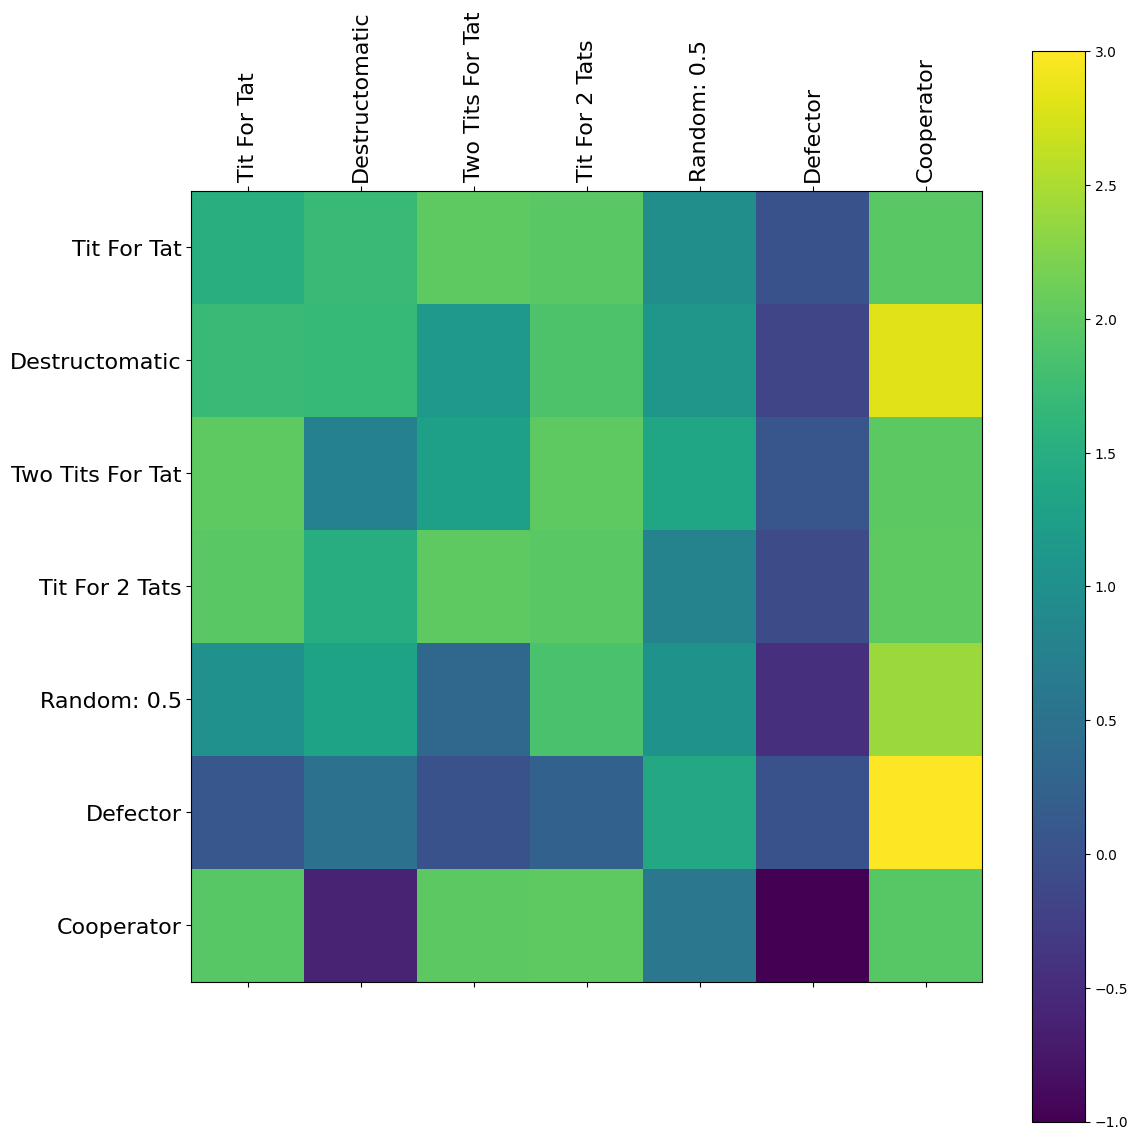

In [ ]:
#Defino una lista con varias estrategias, y defino un torneo con dichas estrategias. En el torneo final, ¡el resto de las estrategias serán las de tus oponentes!
strategies = [Destructomatic(), axelrod.Cooperator(), axelrod.Defector(), axelrod.TitForTat(), axelrod.Random(), axelrod.TwoTitsForTat(), axelrod.TitFor2Tats()]
trnmt = axelrod.Tournament(strategies,
                           game = axelrod.Game(r = 2, s = -1, t = 3, p = 0),
                           turns=200,
                           repetitions=2,
                           prob_end=0.01,
                           noise=0.01)
#Se simula el torneo!
results = trnmt.play()
#Se grafican los resultados
plot = axelrod.Plot(results)
plot.boxplot();
#Matriz de pagos <- se comenta por simplicidad. Descomenta la línea de abajo si te interesa analizar visualmente cómo se ha comportado tu estrategia contra cada una de las demás.
plot.payoff();

***
## Torneo evolutivo
Segunda modalidad de nuestro torneo. Sobre el set de estrategias anteriores, se define un proceso evolutivo. Inicialmente la población de estrategias contiene la misma proporción de individuos jugando a cada estrategia. El número de generaciones simuladas se fija en 1000.

La elección del ganador aquí es un poco más complicada:
 * Si se llega a un **proceso estacionario** (es decir, la proporción de estrategias es aproximadamente constante), **gana quien mayor proporción de individuos tenga**.
 * Puede ocurrir que lleguemos a un **comportamiento periódico** entre varias estrategias (es decir, varias estrategias alternan periodos de dominación). En ese caso, **el ganador es el que más proporción del tiempo ocupe en la franja periódica**.

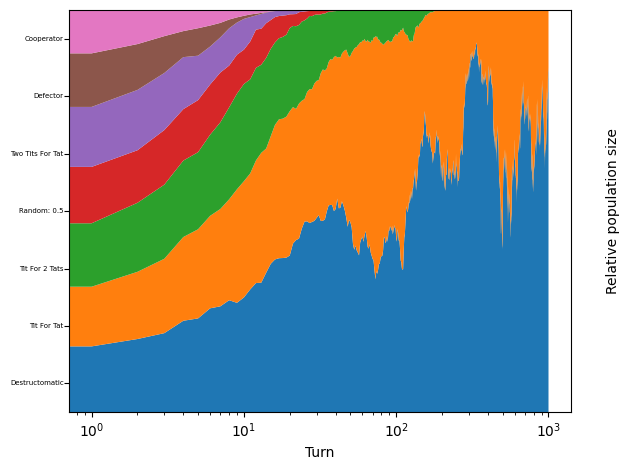

In [15]:
# Se define un ecosistema, se simula y se grafica la evolución
eco = axelrod.Ecosystem(results)
eco.reproduce(1000)
plot.stackplot(eco);

***
## Torneo evolutivo con ecosistema completo
Es la tercera modalidad de nuestro torneo. Las normas son muy similares al caso anterior, pero ahora además de las estrategias presentadas, se incluyen 40 estrategias más, típicas del ecosistema del dilema del prisionero iterado. Son muy numerosas para listarlas aquí, pero ten por seguro que todas las que conoces estarán representadas (y alguna más): el cooperador, el desertor, el alternante, TitForTat, Random, etc.

Playing matches:   0%|          | 0/1128 [00:00<?, ?it/s]

Analysing: 100%|██████████| 25/25 [00:00<00:00, 33.81it/s]


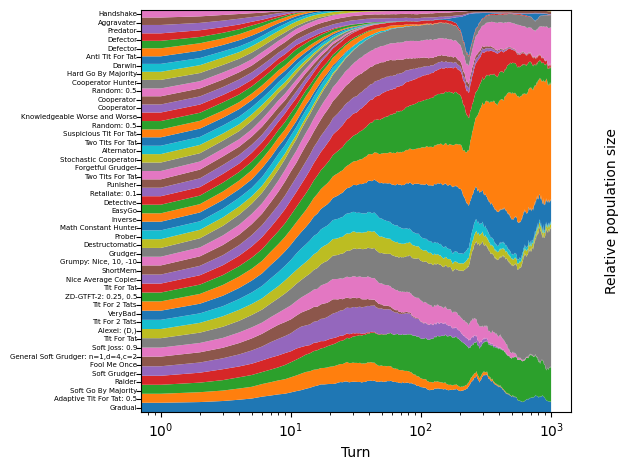

In [16]:
# Se define un ecosistema, se simula y se grafica la evolución
#Defino una lista con varias estrategias, y defino un torneo con dichas estrategias
otherStrategies = [axelrod.GoByMajority(), axelrod.Aggravater(), axelrod.EasyGo(), axelrod.ForgetfulGrudger(), axelrod.GeneralSoftGrudger(), axelrod.SoftGrudger(), axelrod.MathConstantHunter(), axelrod.CooperatorHunter(), axelrod.Detective(), axelrod.AdaptiveTitForTat(), axelrod.AntiTitForTat(), axelrod.TitFor2Tats(), axelrod.TitForTat(), axelrod.TwoTitsForTat(), axelrod.Retaliate(), axelrod.KnowledgeableWorseAndWorse(), axelrod.ZDGTFT2(), axelrod.Alexei(), axelrod.Darwin(), axelrod.FoolMeOnce(), axelrod.Gradual(), axelrod.Handshake(), axelrod.HardGoByMajority(), axelrod.Inverse(), axelrod.Predator(), axelrod.Prober(), axelrod.Punisher(), axelrod.VeryBad(), axelrod.Grudger(), axelrod.Random(), axelrod.SuspiciousTitForTat(), axelrod.Cooperator(), axelrod.Alternator(), axelrod.Defector(), axelrod.StochasticCooperator(), axelrod.SoftJoss(), axelrod.ShortMem(), axelrod.Raider(), axelrod.NiceAverageCopier() , axelrod.Grumpy()]
allStrategies = strategies+otherStrategies
trnmt2 = axelrod.Tournament(allStrategies, repetitions=20, prob_end=0.01, noise=0.01)
results2 = trnmt2.play(progress_bar=True);
eco2 = axelrod.Ecosystem(results2)
eco2.reproduce(1000)
plot2 = axelrod.Plot(results2);
plot2.stackplot(eco2);